In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
import torchvision.utils as vutils
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import ellipse

In [3]:
# This line sets the device to either a gpu or cpu
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(device)

mps


In [4]:
class ConvolutionalAutoencoder(nn.Module):
    def __init__(self, num_channels, out_size):
        super(ConvolutionalAutoencoder, self).__init__()
        self.econv1 = nn.Conv2d(num_channels, 32, kernel_size = 5, bias = False)
        self.ebatch1 = nn.BatchNorm2d(32)
        self.econv2 = nn.Conv2d(32, 8, kernel_size = 5, bias = False)
        self.ebatch2 = nn.BatchNorm2d(8)
        self.econv3 = nn.Conv2d(8, out_size, kernel_size = 56, bias = True)

        self.dconv1 = nn.ConvTranspose2d(out_size, 8, kernel_size = 56, bias = True)
        self.dbatch1 = nn.BatchNorm2d(8)
        self.dconv2 = nn.ConvTranspose2d(8, 32, kernel_size = 5, bias = False)
        self.dbatch2 = nn.BatchNorm2d(32)
        self.dconv3 = nn.ConvTranspose2d(32, num_channels, kernel_size = 5, bias = False)

    def encoder(self, x):
        y1 = F.elu(self.ebatch1(self.econv1(x)))
        y2 = F.elu(self.ebatch2(self.econv2(y1)))
        z = self.econv3(y2)
        return z

    def decoder(self, z):
        y1 = F.elu(self.dbatch1(self.dconv1(z)))
        y2 = F.elu(self.dbatch2(self.dconv2(y1)))
        x = torch.sigmoid(self.dconv3(y2))
        return x
     
    def forward(self, x):
        z = self.encoder(x)
        y = self.decoder(z)
        return y

In [57]:
def train(autoencoder, data_loader, num_epochs = 20, learn_rate = 0.5, weight_decay = 0.0):
    optimizer = torch.optim.SGD(autoencoder.parameters(), lr = learn_rate, weight_decay = weight_decay)
    mse_loss = nn.MSELoss()

    for epoch in range(num_epochs):
        tot_loss = 0
        for i, (x, label) in enumerate(data_loader):
            x = x.to(device)
            y = autoencoder(x)

            loss = mse_loss(x, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            tot_loss = tot_loss + loss.data.cpu().numpy()

        print(epoch, ": Loss =", tot_loss)
        
    return autoencoder

In [58]:
N = 1000           # training data size
batch_size = 100   # set a batch size that works for you (might just use N)
num_channels = 1   # set this to 1 for ellipse (grayscale) and 3 for teapot (colbor)

# Replace the line below with your generated ellipse images training dataset

rng = np.random.default_rng()

data = np.zeros((N, 64, 64))
rows = rng.uniform(16, 48, N)
cols = rng.uniform(16, 48, N)

for i in range(N):
    e = ellipse.get_ellipse(a = 12, b = 6, row = rows[i], col = cols[i], theta = 0)

    data[i] = e

X = torch.Tensor(data).unsqueeze(1)

print(X.shape)

# These are dummy labels needed to create pytorch TensorDataset
y = torch.zeros(N)
print(y.shape)


train_data = TensorDataset(X, y)
train_loader = DataLoader(train_data, batch_size = batch_size, shuffle = True)

torch.Size([1000, 1, 64, 64])
torch.Size([1000])


In [59]:
latent_dim = 2 # set your latent dimension here

convAE16 = ConvolutionalAutoencoder(num_channels, latent_dim)
convAE16 = train(convAE16.to(device), train_loader)

0 : Loss = 1.5035523
1 : Loss = 0.57767373
2 : Loss = 0.41821218
3 : Loss = 0.3405097
4 : Loss = 0.3127144
5 : Loss = 0.26106983
6 : Loss = 0.26232433
7 : Loss = 0.260548
8 : Loss = 0.258489
9 : Loss = 0.21889421
10 : Loss = 0.2270058
11 : Loss = 0.21153326
12 : Loss = 0.20146978
13 : Loss = 0.18416038
14 : Loss = 0.1902167
15 : Loss = 0.17582439
16 : Loss = 0.17616768
17 : Loss = 0.16782218
18 : Loss = 0.15690272
19 : Loss = 0.15983199


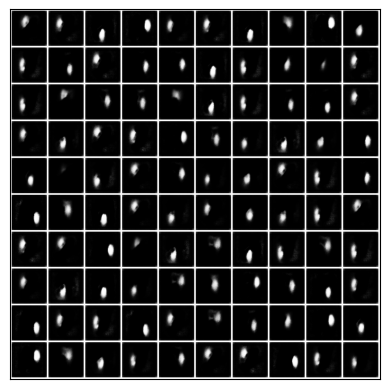

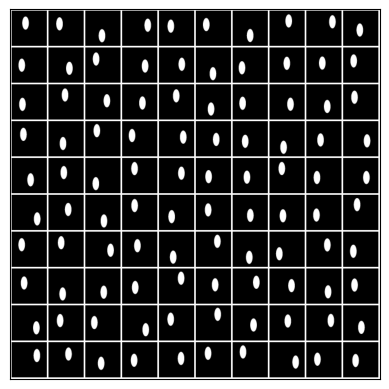

In [60]:
# Testing
rows_test, cols_test = rng.uniform(16, 48, 100), rng.uniform(16, 48, 100)

test = np.zeros((100, 1, 64, 64))

for id, (r, c) in enumerate(zip(rows_test, cols_test)):
    e = ellipse.get_ellipse(a = 12, b = 6, row = r, col = c, theta = 0)
    test[id, 0] = torch.Tensor(e)

test_tensor = torch.from_numpy(test).float().to(device)
# making grid
with torch.no_grad():
    y = convAE16.forward(test_tensor)

def show(imgs): ## from pytroch tutorial
    if not isinstance(imgs, list):
        imgs = [imgs]
    fig, axs = plt.subplots(ncols=len(imgs), squeeze=False)
    for i, img in enumerate(imgs):
        img = img.detach().cpu()
        img = transforms.functional.to_pil_image(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

grid_r = vutils.make_grid(y, nrow = 10, pad_value = 1, padding=3)
grid_t =  vutils.make_grid(test_tensor, nrow = 10, pad_value = 1, padding=3)
show(grid_r)
show(grid_t)

In [1]:
# Load the teapot images
# NOTE: there are 10,000 images -- you can subsample a smaller number,
# e.g., 1000 for training and 100 (separate) for testing
X = torch.load("teapot.pth", weights_only = True)

NameError: name 'torch' is not defined

In [ ]:
# Sanity check to make sure tensor has correct size, should be 10,000 x 3 x 64 x 64
print(X.shape)

# Display the first image to make sure it loaded correctly
plt.imshow(X[0,:,:,:].permute((1,2,0)))
plt.show()